In [3]:
#Carregando bibliotecas e datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

users = pd.read_csv(
    "../data/processed/users_clean.csv"
)

user_plan = pd.read_csv(
    "../data/processed/user_plan_clean.csv",
    parse_dates=["data_inicio"]
)

user_app = pd.read_csv(
    "../data/processed/user_app_clean.csv",
    parse_dates=["checkin"]
)

activities = pd.read_csv(
    "../data/processed/activities_clean.csv",
    parse_dates=["date"]
)

weekly_visits = pd.read_csv(
    "../data/processed/weekly_visits_clean.csv"
)

challenges = pd.read_csv(
    "../data/processed/challenges_clean.csv",
    parse_dates=["data_inicio", "data_fim"]
)

desafio_usuario = pd.read_csv(
    "../data/processed/desafio_usuario_clean.csv",
    parse_dates=["data_desafio"]
)

In [4]:
#Revendo o tamanho dos datasets
datasets = {
    'users': users,
    'user_plan': user_plan,
    'user_app': user_app,
    'activities': activities,
    'weekly_visits': weekly_visits,
    'challenges': challenges,
    'desafio_usuario': desafio_usuario
}

for name, df in datasets.items():
    print(f'\n{name}')
    print(df.shape)


users
(1000, 4)

user_plan
(1227, 3)

user_app
(12261, 4)

activities
(13144, 9)

weekly_visits
(9735, 4)

challenges
(50, 4)

desafio_usuario
(496, 4)


##EDA Univariado

#Dataset de usuários

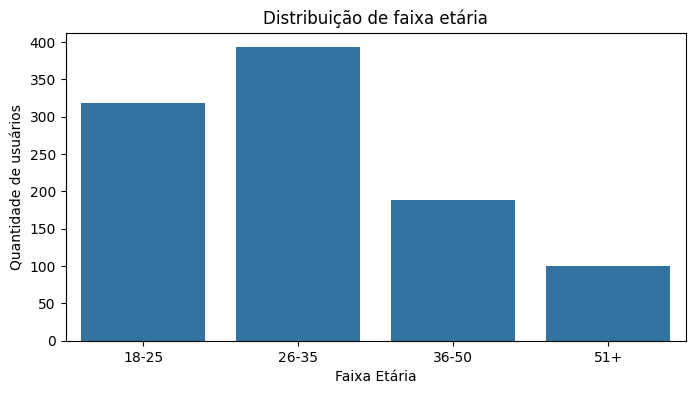

In [5]:
#Verificando a distribuição de idade
os.makedirs('../outputs/EDA', exist_ok=True)

order = ['18-25', '26-35', '36-50', '51+']

plt.figure(figsize=(8,4))
sns.countplot(data=users, 
    x='age_group',
    order=order
)
plt.title('Distribuição de faixa etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de usuários')

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()


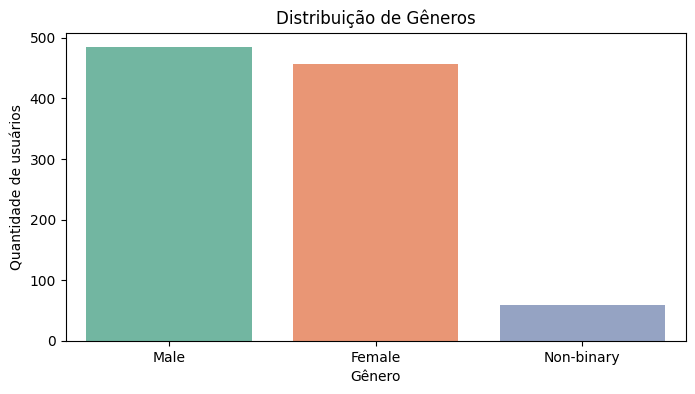

In [6]:
#Verificando a distribuição de gênero
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(8,4))

sns.countplot(data=users, 
    x='gender',
    hue='gender',
    palette='Set2',
    legend=False
)
plt.title('Distribuição de Gêneros')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de usuários')

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

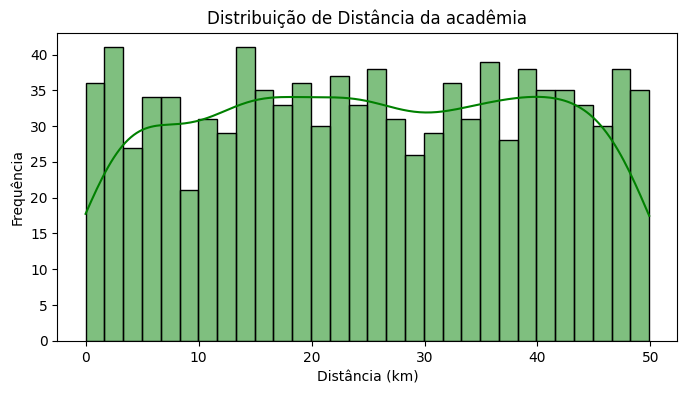

In [7]:
#Verificando a distribuição de da distância da acadêmia
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(8,4))

sns.histplot(data=users, 
    x='distance_to_gym',
    bins=30,
    kde=True,
    color='green'
)
plt.title('Distribuição de Distância da acadêmia')
plt.xlabel('Distância (km)')
plt.ylabel('Frequência')

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

#Dataset de Planos do Usuários

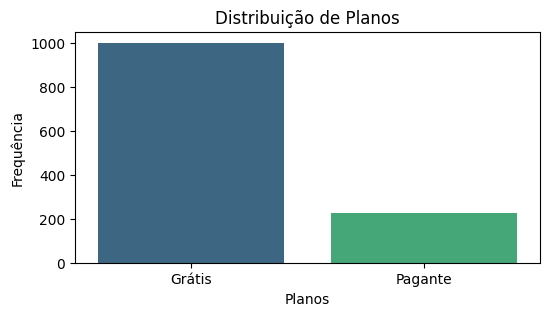

In [8]:
#Verificando os planos disponíveis
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(6,3))
sns.countplot(data=user_plan, 
    x='plano',
    hue='plano',
    palette='viridis',
    legend=False
)
plt.title('Distribuição de Planos')
plt.xlabel('Planos')
plt.ylabel('Frequência')

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

In [9]:
#Transformando a data de início em mês-ano
user_plan['mes_ano'] = user_plan['data_inicio'].dt.to_period('M')
planos_por_mes = user_plan['mes_ano'].value_counts().sort_index()

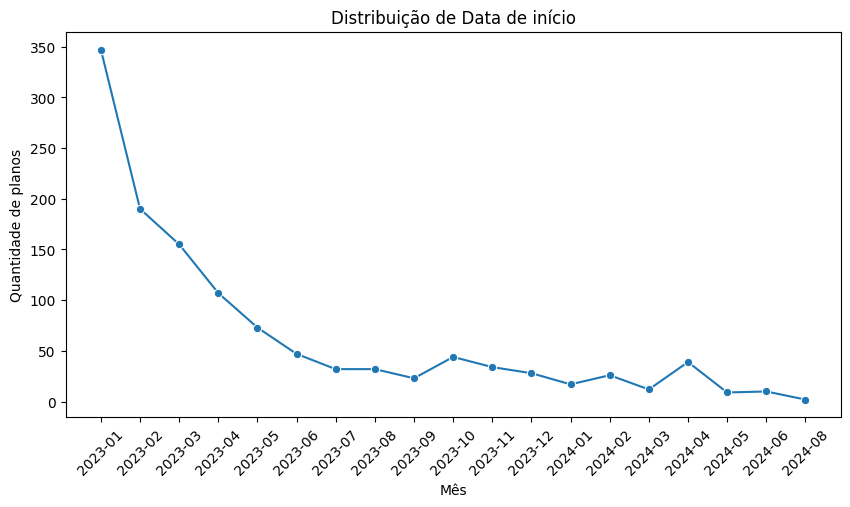

In [10]:
#Verificando a distribuição de datas de início
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=planos_por_mes.index.astype(str),
    y=planos_por_mes.values,
    marker='o'
)
plt.title('Distribuição de Data de início')
plt.xlabel('Mês')
plt.ylabel('Quantidade de planos')
plt.xticks(rotation=45)

file_path = f"../outputs/EDA/lineplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

#Dataset de Aplicativos dos Usuários

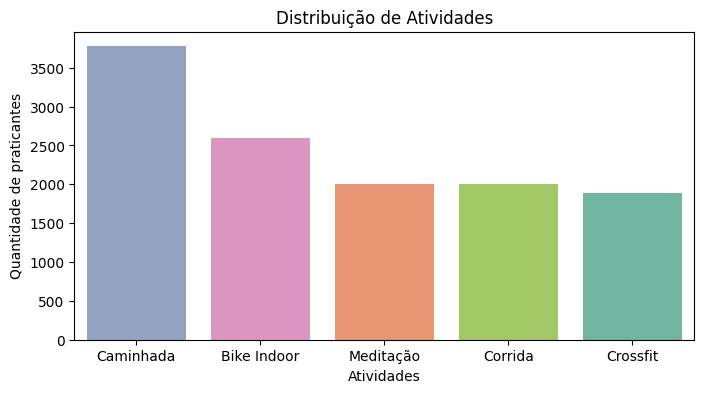

In [11]:
#Verificando as atividades realizadas
os.makedirs('../outputs/EDA', exist_ok=True)

order = user_app['atividade'].value_counts().index

plt.figure(figsize=(8,4))

sns.countplot(data=user_app, 
    x='atividade',
    order=user_app['atividade'].value_counts().index,
    hue='atividade',
    palette='Set2',
    legend=False
)
plt.title('Distribuição de Atividades')
plt.xlabel('Atividades')
plt.ylabel('Quantidade de praticantes')

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

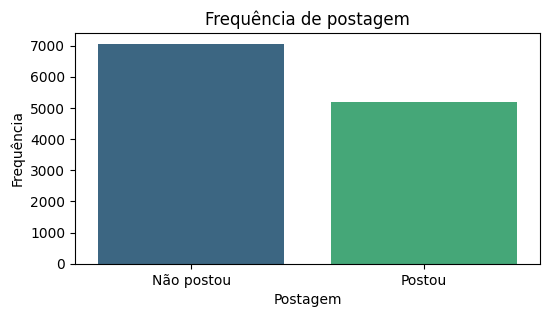

In [12]:
#Verificando a frequência de postagem
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(6,3))
sns.countplot(data=user_app, 
    x='post',
    hue='post',
    palette='viridis',
    legend=False
)
plt.title('Frequência de postagem')
plt.xlabel('Postagem')
plt.ylabel('Frequência')
plt.xticks([0,1], ['Não postou', 'Postou'])

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

In [13]:
#Transformando os checkins em mês-ano
user_app['mes_ano'] = user_app['checkin'].dt.to_period('M')
checkin_por_mes = user_app['mes_ano'].value_counts().sort_index()

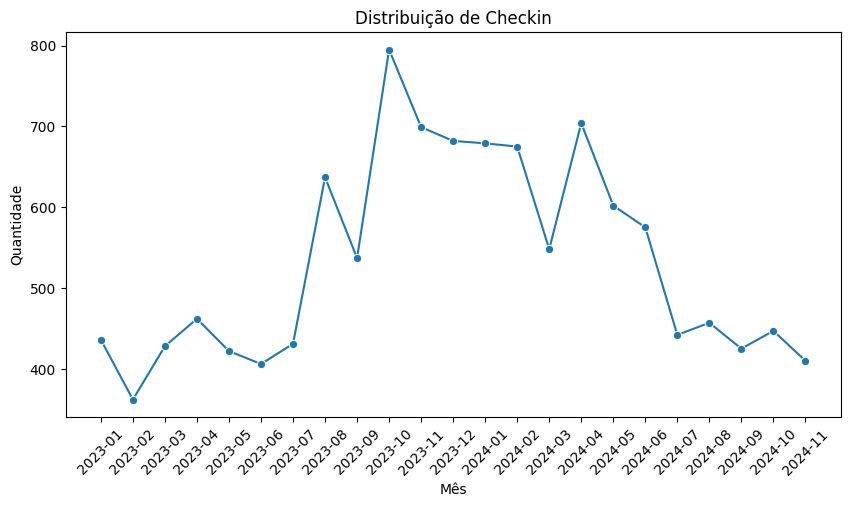

In [14]:
#Verificando a distribuição de checkins
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=checkin_por_mes.index.astype(str),
    y=checkin_por_mes.values,
    marker='o'
)
plt.title('Distribuição de Checkin')
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

file_path = f"../outputs/EDA/lineplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

#Dataset de Atividades

In [15]:
#Steps

In [16]:
#Minutes_meditated

In [17]:
#Activity_type

In [18]:
#Date

In [19]:
#Calories_burned

In [20]:
#Gym_visit

In [21]:
#Week

#Dataset de Visitas Semanais

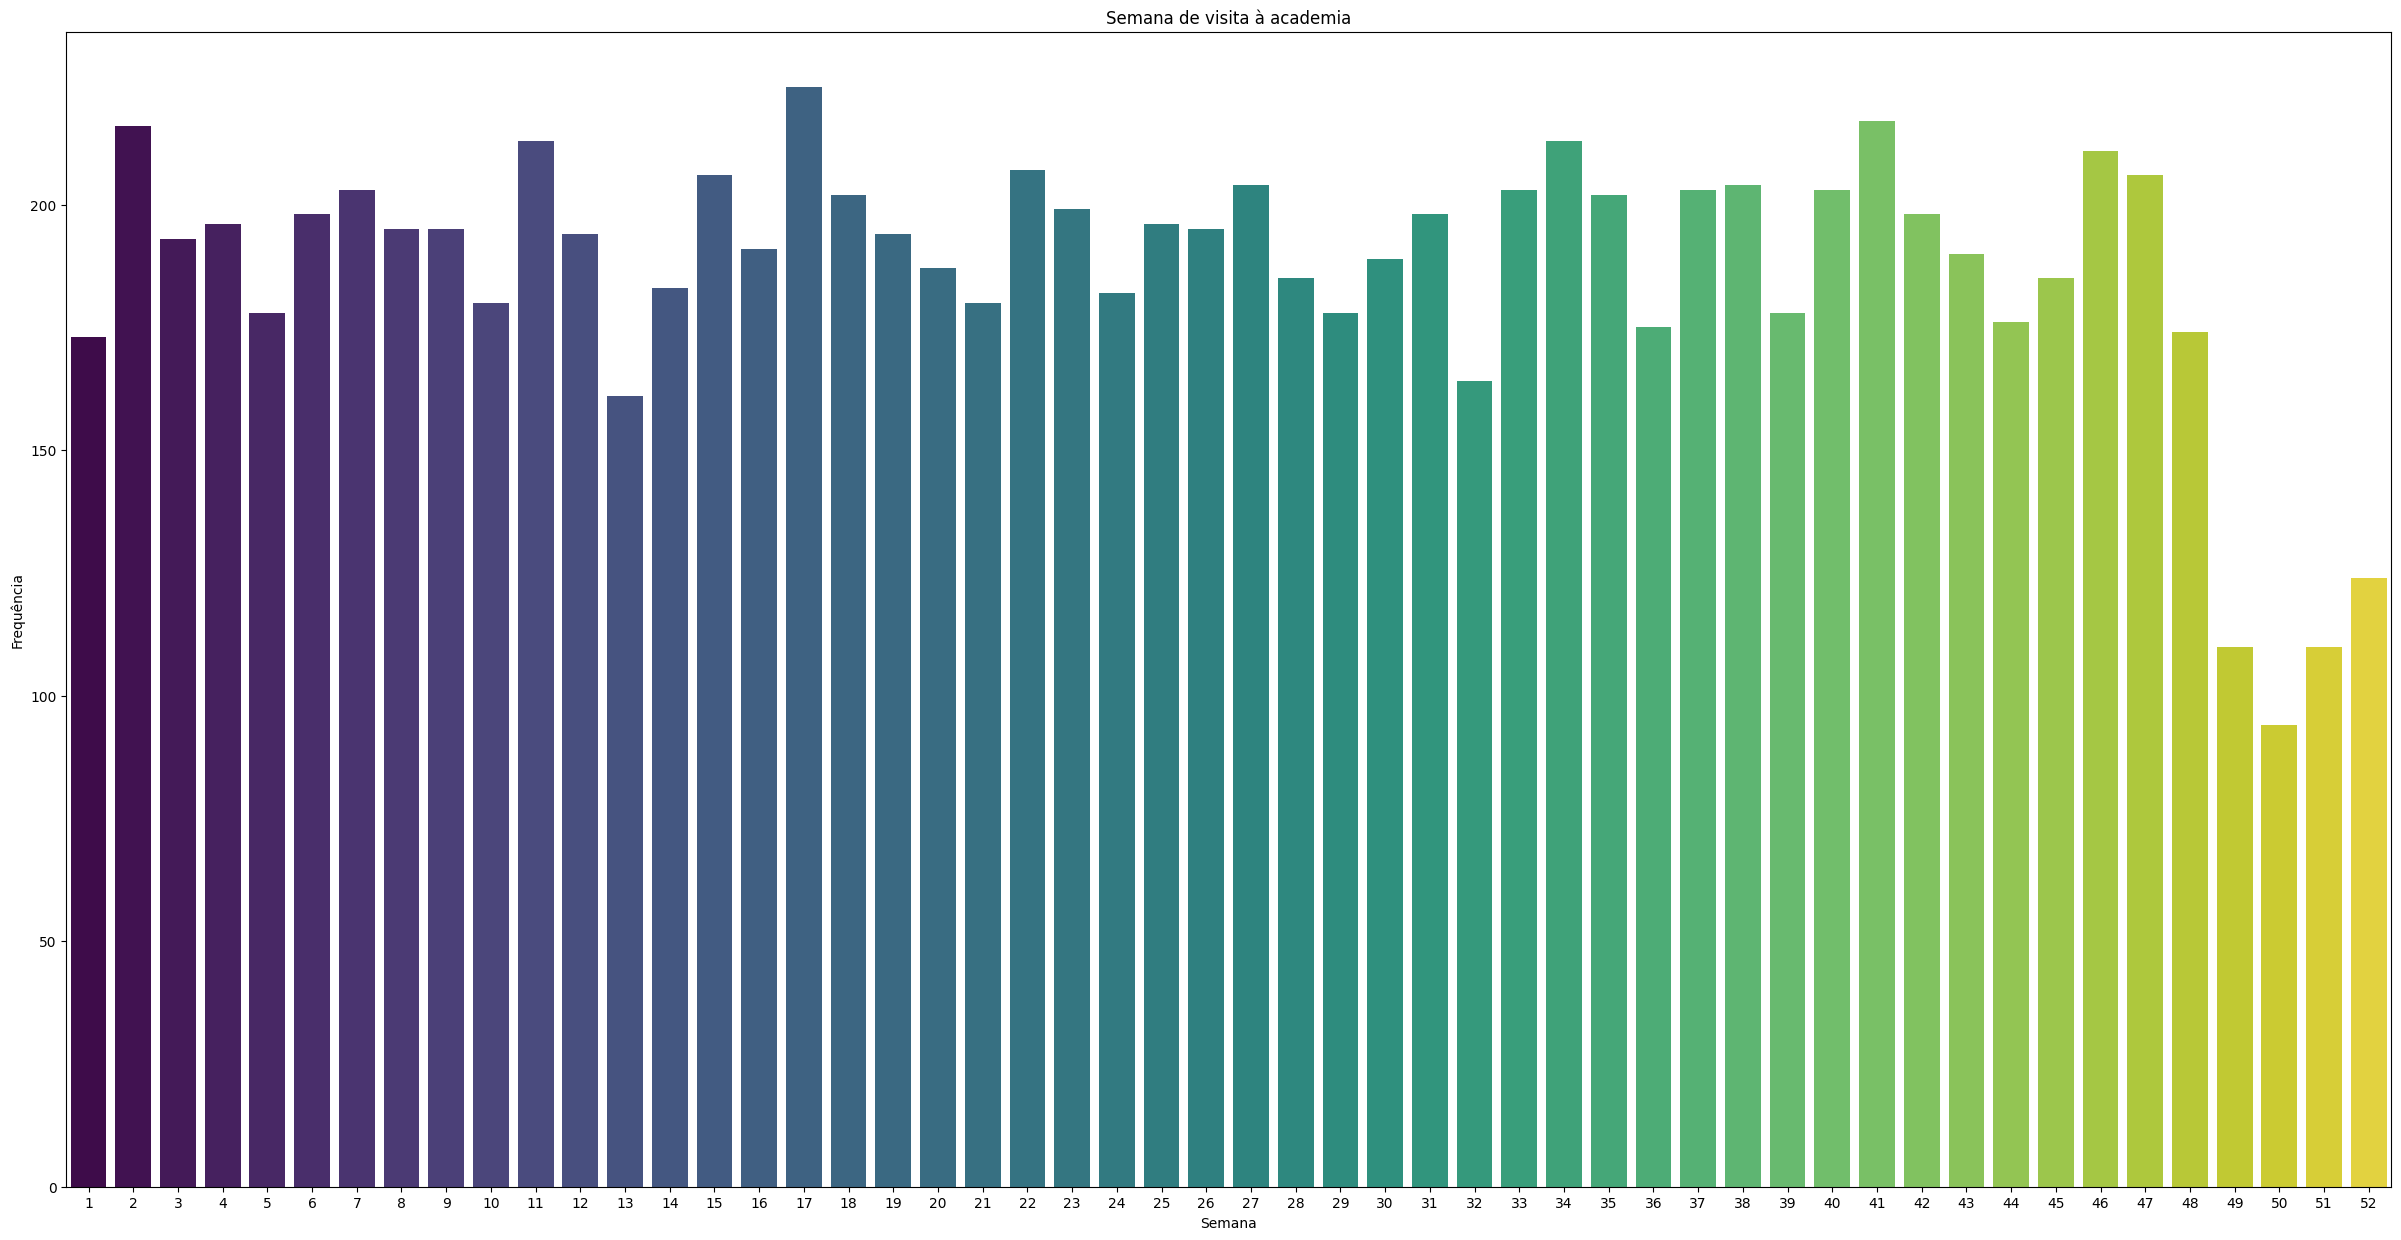

In [22]:
#Verificando a frequência de postagem
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(30,15))
sns.countplot(data=weekly_visits, 
    x='week',
    hue='week',
    palette='viridis',
    legend=False
)
plt.title('Semana de visita à academia')
plt.xlabel('Semana')
plt.ylabel('Frequência')

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

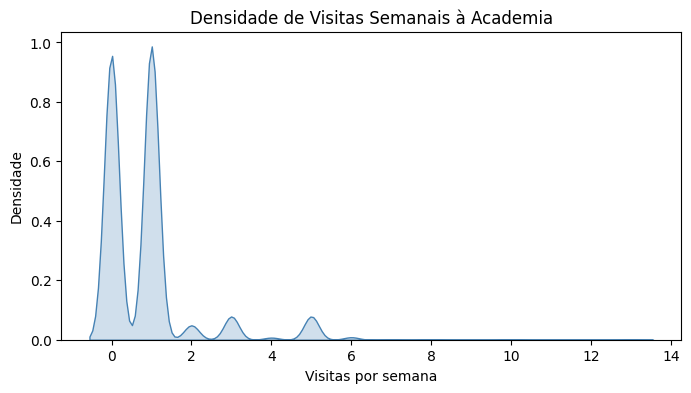

In [32]:
#Verificando a frequência de postagem
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(8,4))
sns.kdeplot(data=weekly_visits, 
    x='weekly_gym_visits',
    fill=True,
    color='steelblue'
)
plt.title('Densidade de Visitas Semanais à Academia')
plt.xlabel('Visitas por semana')
plt.ylabel('Densidade')

file_path = f"../outputs/EDA/kdeplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
#Transformando os checkins em mês-ano
user_app['mes_ano'] = user_app['checkin'].dt.to_period('M')
checkin_por_mes = user_app['mes_ano'].value_counts().sort_index()

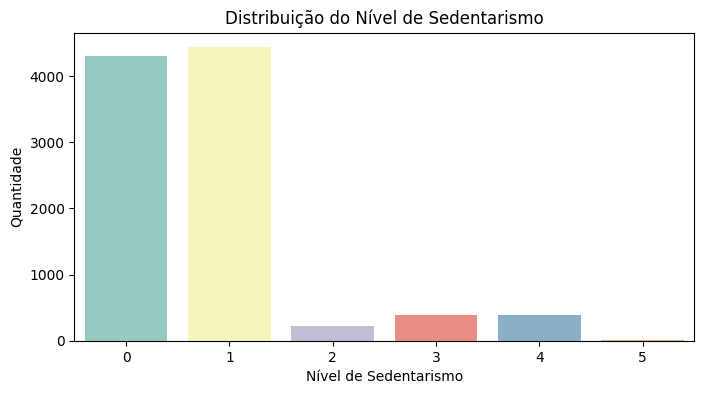

In [25]:
#Verificando o nível de sedentarismo
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(8,4))
sns.countplot(data=weekly_visits, 
    x='sedentarism_level',
    hue='sedentarism_level',
    palette='Set3',
    legend=False
)
plt.title('Distribuição do Nível de Sedentarismo')
plt.xlabel('Nível de Sedentarismo')
plt.ylabel('Quantidade')

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

#Dataset de Desafios

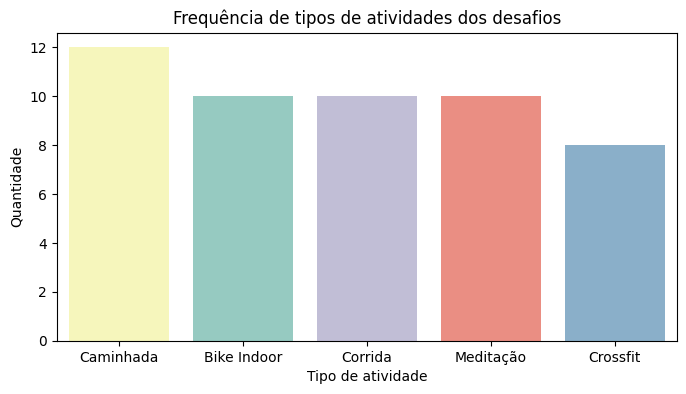

In [27]:
#Verificando os tipos de desafios
os.makedirs('../outputs/EDA', exist_ok=True)

order = challenges['activity_type'].value_counts().index

plt.figure(figsize=(8,4))
sns.countplot(data=challenges, 
    x='activity_type',
    order=order,
    hue='activity_type',
    palette='Set3',
    legend=False
)
plt.title('Frequência de tipos de atividades dos desafios')
plt.xlabel('Tipo de atividade')
plt.ylabel('Quantidade')

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
#Transformando as datas de início em mês-ano
challenges['data_inicio'] = challenges['data_inicio'].dt.to_period('M')
desafio_inicio_por_mes = challenges['data_inicio'].value_counts().sort_index()

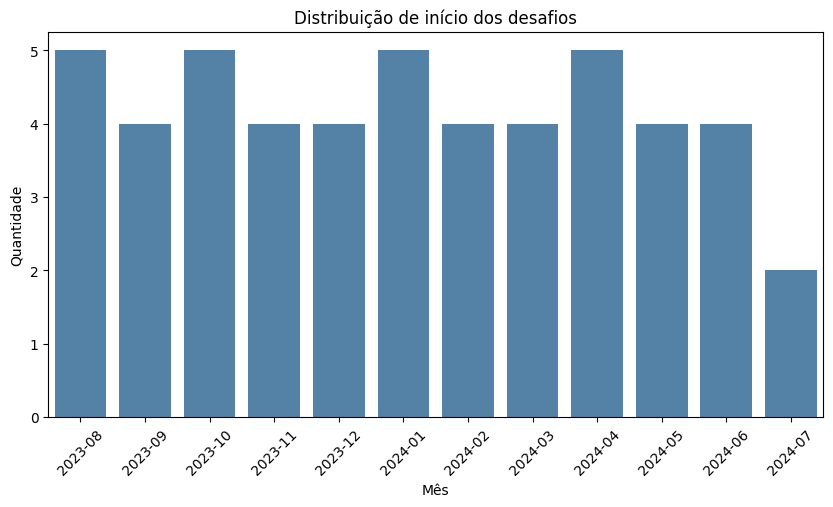

In [ ]:
#Verificando as datas de início do desafio
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(10,5))

sns.barplot(
    x=desafio_inicio_por_mes.index.astype(str),
    y=desafio_inicio_por_mes.values,
    color='steelblue'
)
plt.title('Distribuição de início dos desafios')
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

file_path = f"../outputs/EDA/lineplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
#Transformando as datas-fim em mês-ano
challenges['data_fim'] = challenges['data_fim'].dt.to_period('M')
data_final_desafio_por_mes = challenges['data_fim'].value_counts().sort_index()

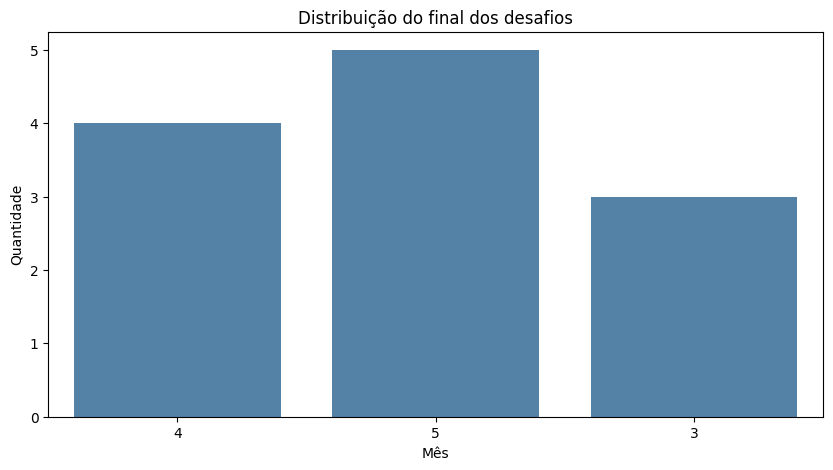

In [ ]:
#Verificando a distribuição de checkins
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(10,5))

sns.barplot(
    x=data_final_desafio_por_mes.astype(str),
    y=data_final_desafio_por_mes,
    color='steelblue'
)
plt.title('Distribuição do final dos desafios')
plt.xlabel('Mês')
plt.ylabel('Quantidade')

file_path = f"../outputs/EDA/lineplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

#Dataset de Desafios por Usuário

In [ ]:
#Transformando as data-desafio em mês-ano
desafio_usuario['data_desafio'] = desafio_usuario['data_desafio'].dt.to_period('M')
data_desafio_usuario = desafio_usuario['data_desafio'].value_counts().sort_index()

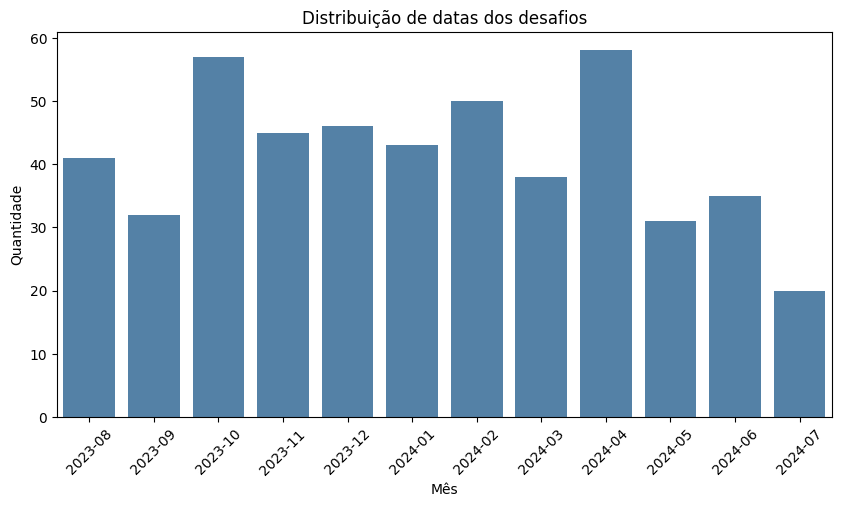

In [ ]:
#Verificando as datas dos desafios
os.makedirs('../outputs/EDA', exist_ok=True)

plt.figure(figsize=(10,5))

sns.barplot(
    x=data_desafio_usuario.index.astype(str),
    y=data_desafio_usuario,
    color='steelblue'
)
plt.title('Distribuição de datas dos desafios')
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

file_path = f"../outputs/EDA/lineplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

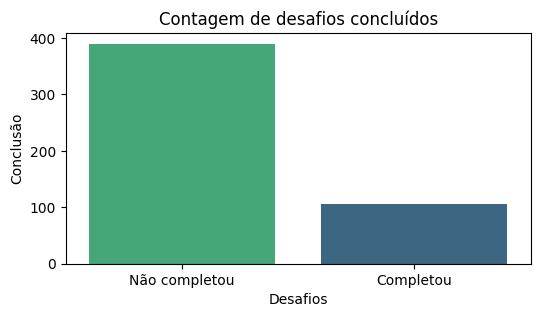

In [28]:
#Verificando quantos completaram os desafios
os.makedirs('../outputs/EDA', exist_ok=True)

order = desafio_usuario['completou'].value_counts().index

plt.figure(figsize=(6,3))
sns.countplot(data=desafio_usuario, 
    x='completou',
    order=order,
    hue='completou',
    palette='viridis',
    legend=False
)
plt.title('Contagem de desafios concluídos')
plt.xlabel('Desafios')
plt.ylabel('Conclusão')
plt.xticks([0,1], ['Não completou', 'Completou'])

file_path = f"../outputs/EDA/countplot_{name}.png"
    
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()